# Project 1: Panorama! (Total 100 points)

The primary objective of this project is to develop a comprehensive end-to-end pipeline for panorama stitching, similar to the panorama mode available on modern smartphones. Panorama stitching is a technique used to seamlessly combine multiple photographs to create a single, wide-angle seamless image that captures a broader view than a single shot could achieve.

<b>Each image should have few repeated local features (∼30−50% or more, emperically chosen)</b>. The following method of stitching images should work for most image sets but you’ll need to be creative for working on harder image sets.


From a set of narrow field of view unordered pair of images:

<img src="https://drive.google.com/uc?export=view&id=1I2vSX5lCQiMZ1H1YffiyGKKR0VzFbwkD">

To a Seamless Panorama:

<img src="https://drive.google.com/uc?export=view&id=1nYI-tK_TFXwe0Qvdxw7QVmFCCb5hUBHp">


---


Overview:
<img src="https://drive.google.com/uc?export=view&id=1S9auoknXW7MXjB5MCXsjqblx_iitk3H-">



<hr>

# Submission Guidelines
The project is to be submitted on Canvas.

1. Each group will only submit one ‘zip’ file named <student1_student2_p1.zip> The zip file is to be submitted on Canvas (submission portal will open on Monday). Zip file should not exceed more than 100MB.
2. Each zip file MUST contain:<br>
A. Link to Google Colab File (Link should have open access; DO NOT share with this link with anyone else) <br>
B. PDF Output of your Google Colab with results <br>
C. PDF Report in IEEE Trans/Conf LaTeX format. The report must contain all the images of results at every step. Talk about what you did to blend common region between images. Talk about how you rejected images with no/very less overlaps.
<hr>

# Change Runtime Type to T4 GPU:


<b>Note</b>: _It is not required for P1 but for following projects that involve deep learning. Feel free to skip this step._

1. Click on "Runtime" in the menu bar.
2. Select "Change runtime type".
3. Choose "T4" from the "Hardware accelerator" dropdown menu.
4. Click "Save".

In [1]:
# Make Sure NVIDIA T4 GPU is connected:

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

/bin/bash: line 1: nvidia-smi: command not found


# Part A: Input Images



Overview:
<img src="https://drive.google.com/uc?export=view&id=17CubCdTxpJMTPMxAxBbqAuDN7pZXpTPG">


In [2]:
# Download training images from Google Drive
import gdown

# VictoriaLibrary
gdown.download_folder(id="14lVfW-ss6qo24PvcVdlBNW0o40u6QlOw", quiet=True, use_cookies=False)

##############################################################################################
# The following dataset will be released later one week after the release date of this project
# Until then, please work only on VictoriaLibrary Dataset
##############################################################################################

# Flatirons
# gdown.download_folder(id="1cwLOG_4keUaQHmp5RVwe_ZiAHeULpjOd", quiet=True, use_cookies=False)

# CUBoulderSatView
# gdown.download_folder(id="10WcuZFuCxbe1FQSwpdy_9piyMM45eOI_", quiet=True, use_cookies=False)

# CULogo
# gdown.download_folder(id="1Pv7eI-LOOUZxHffz1D5pmMKOk-Y7C-kx", quiet=True, use_cookies=False)

# Checkerboard
# gdown.download_folder(id="1xPzK5se5AICqffjfuedqgiovQse4ILkS", quiet=True, use_cookies=False)

# Indoors
# gdown.download_folder(id="1RfDSald_h2kwxRbcu8iq6ZPJ8TjOEGzK", quiet=True, use_cookies=False)

# FlatironsChallenge
# gdown.download_folder(id="16_AV0IAfdr594jE_rK7serWNsVeN7wCS", quiet=True, use_cookies=False)

# YourData
# gdown.download_folder(id="1xquJuwrwNBq0QEbwqB0LyJ6CAgHxa1lS", quiet=True, use_cookies=False)

['/content/VictoriaLibrary/1.jpg',
 '/content/VictoriaLibrary/2.jpg',
 '/content/VictoriaLibrary/3.jpg']

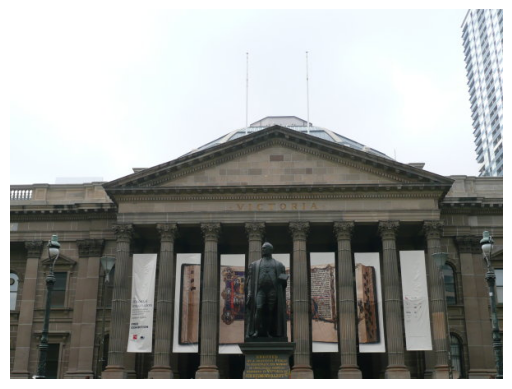

In [3]:
######################################
## Plot Images using Matplotlib:
######################################

# Import Libraries: (Feel free to modify according to your needs)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy import ndimage
import numpy as np
import cv2
# import os
# from google.colab.patches import cv2_imshow
img = 'VictoriaLibrary/1.jpg'
img = mpimg.imread(img)

# Display Function for plotting an image using Matplotlib:
# You can also use CV2 plotting function
def show_img(img):
    plt.imshow(img)
    plt.axis("off")
    plt.show()

show_img(img)

# Part B: Detect Corners [5 pts]

## In this part, you will:

1.   Detect corners
2.   Display corners on top of the images

Sample Corner Detection:<br>
<img src="https://drive.google.com/uc?export=view&id=10C8SAWpfkTY054DOFo6he8KP_tPW3oQw">


The objective of this step is to detect corners such that they are equally distributed across the image in order to avoid weird artifacts in warping. Corners in the image can be detected using `cv2.cornerHarris` function with the appropriate parameters. The output is a matrix of corner scores: the higher the score, the higher the probability of that pixel being a corner.




In [4]:
# 1. Reduce the image size (optional) for faster processing
# 2. Convert Image to gray scale image (Try 'cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)')
# 3. Detect Corners (Use 'cv2.cornerHarris' or 'cv2.goodFeaturesToTrack' or equivalent functions)
# 4. Plot the corners on the image
# Refer: https://docs.opencv.org/3.4/dc/d0d/tutorial_py_features_harris.html

# Note: Make sure you select and plot N_Strong corners i.e. Select the corners with high corner response score
# Refer: https://medium.com/@erhan_arslan/delving-into-corner-detection-with-python-harris-corner-detector-71231f9f44e2

# Refer:
# from scipy.ndimage import maximum_filter

'''
Detect Corners in the Image:
Input: Image
Output: N_Strong Corners and corner response map (cmap)
'''
def detect_corner(img):
  N = 400

  # Convert to gray scale
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # Perform corner detection here:
  dst = cv2.cornerHarris(img_gray, 2, 3, 0.04)
  # print(dst.shape, dst[0][0])

  # Setting a threshold
  # threshold = 0.01 * dst.max()
  # # Getting coordinates of corners above the threshold
  # N_Strong = np.where(dst > threshold)

  # Get N strongest corners
  flattened_strongest = np.argpartition(dst.ravel(), -N)[-N:]
  N_Strong = np.unravel_index(flattened_strongest, dst.shape)

  # Return the a set of N_Strong Corners and corner response map (cmap)
  return N_Strong, dst

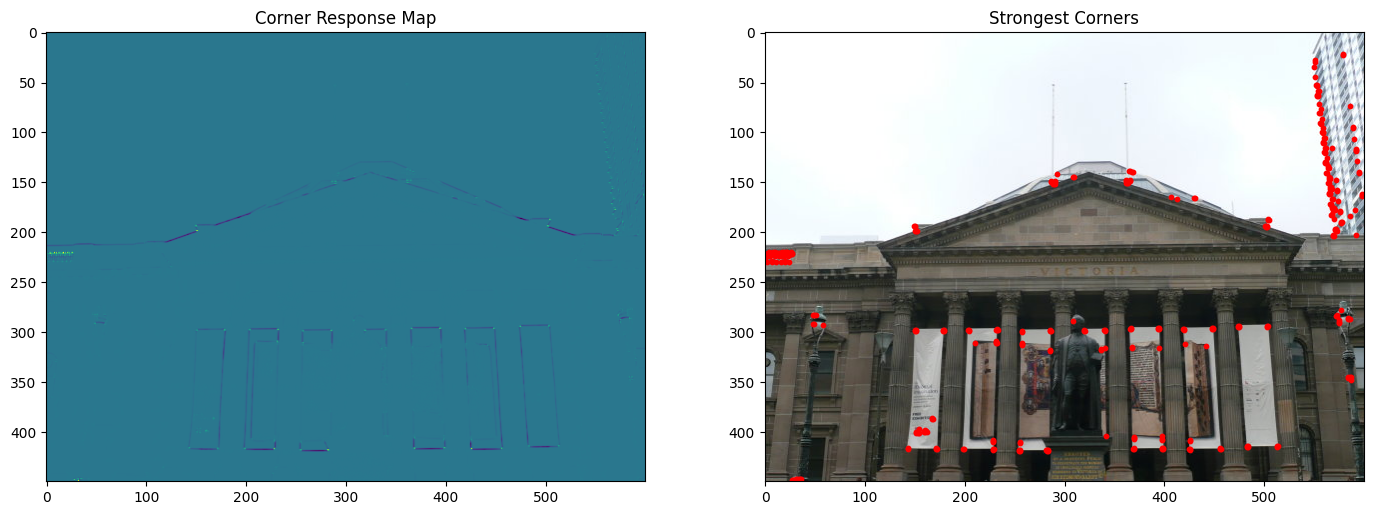

In [5]:
# Plot your corners here:
N_strong, dst = detect_corner(img)

plt.figure(figsize=(17, 10))
plt.subplot(121)
plt.title('Corner Response Map')
plt.imshow(dst)

plt.subplot(122)
plt.imshow(img)
plt.scatter(N_strong[1], N_strong[0], color='red', s = 10)
plt.title('Strongest Corners')
plt.show()

# Part 3: ANMS [10 pts]




In this part, you will:
1.   Select $N$ best corners that are equally spaced through out the image using <b>ANMS</b> (Adaptive Non-Maximal Suppression)
2.   Create Feature Descriptors from Corners

Sample Corner Detection after ANMS:<br>
<img src="https://drive.google.com/uc?export=view&id=1Jihg0GOuppYSXOhuQXt6jc5zfbwqCu0d">

---



To find particular strong corners that are spread across the image, first we need to find $N_{strong}$ corners. Because, when you take a real image, the corner is never perfectly sharp, each corner might get a lot of hits out of the $N_{strong}$ corners - we want to choose only the $N_{best}$ corners after ANMS. In essence, you will get a lot more corners than you should! ANMS will try to find corners which are local maxima.

## ANMS Algorithm:


<img src="https://drive.google.com/uc?export=view&id=1_t7wiw4cFeIHji8AWwcvias-7AI210i0">

Note: Python's `scipy.ndimage.filters.maximum_filter` is similar to `imregionalmax` from MATLAB.

Intuitively, we are trying to find $N_{best}$ corners, say `200` from `500` $N_{strong}$ corners such that they are equally distant from one another. To do sp, we define an adaptive radius $r_i$ as the distance between two feature points `i` and `j`.

<img src="https://drive.google.com/uc?export=view&id=1lx1VfylVBxejl-m0baRe8Kklkb-gHeKn">


In [6]:
'''
ANMS Algorithm:
Input: Corner Response Map, N_Strong Corner Set, nBest Number of Best Corners
Output: N_Best Corners Set
'''
def anms(cmap, N_Strong, nBest):
  # Perform ANMS here:
  # Return the a set of N_best Corners

  N_strong_num = len(N_Strong[0])
  r = np.full(N_strong_num, np.inf)
  for i in range(N_strong_num):
    for j in range(N_strong_num):
        ED = np.inf
        x_i, y_i = N_Strong[1][i], N_Strong[0][i]
        x_j, y_j = N_Strong[1][j], N_Strong[0][j]
        if (cmap[y_j, x_j] > cmap[y_i, x_i]):
            ED = (x_j - x_i)**2 + (y_j - y_i)**2
        if (ED < r[i]):
            r[i] = ED
  sorted_r = np.argsort(r)[::-1] #[::-1] is descending order
  sorted_N_strong = np.array(N_Strong)[:, sorted_r]
  return sorted_N_strong[:, :nBest]

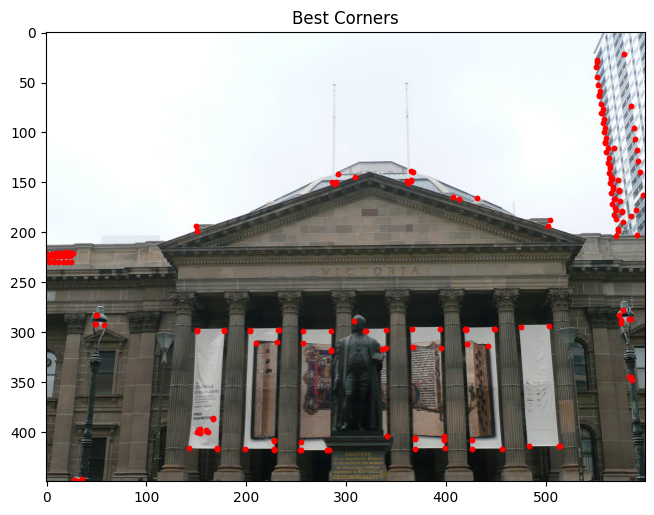

In [7]:
# Plot N_Best corners and compare them with N_Strong
N_best = anms(dst, N_strong, 200)
plt.figure(figsize=(17, 10))
plt.subplot(122)
plt.imshow(img)
plt.scatter(N_best[1], N_best[0], color='red', s = 10)
plt.title('Best Corners')
plt.show()

# Part 4: Feature Descriptors [15 pts]


In the previous step, you found the feature points (locations of the N best best corners after ANMS are called the feature points). You need to describe each feature point by a feature vector, this is like encoding the information at each feature points by a vector. One of the easiest feature descriptor is described next. <br>
<b>Note:</b> <u>The following kernel/patch/vector sizes are user chosen. Feel free to modify them according to your data</u>

---

Sample Feature Desciptors:<br>
<img src="https://drive.google.com/uc?export=view&id=1f5yY-P6SCTdL68rm3Hr4ofD0vgIY_wWe">

---
<br>

1. Take a patch of size `40×40` centered (this is very important and depends on the input image resolution) around the keypoint.
2. Now apply `gaussian blur` (feel free to play around with the parameters and use `cv.GaussianBlur()` function).
3. Now, sub-sample the blurred output (this reduces the dimension) to `8×8`.
4. `reshape` it to obtain a `64×1` vector.
5. `Standardize` the vector to have `mean` of `0` and `variance` of `1` (This can be done by subtracting all values by mean and then dividing by the standard deviation). Note: Standardization is used to remove bias and some illumination effect.


---

In [8]:
'''
Feature Descriptor:
Input: Corner Coordinates, Image
Output: Feature Descriptors
'''
def feature_desc(gray_img, N_Best):
  # Generate Feature Descriptor For Corners Here
  # 1. Define Patch Size, Blur Kernels and Subsample Size
  patch_size = 40
  blur_kernel_size = 3
  subsample_size = 8
  n = N_Best.shape[1]

  padded_img = cv2.copyMakeBorder(gray_img, 40, 40, 40, 40, cv2.BORDER_REFLECT)

  desc = []
  des_coord = []
  for i in range(n):
    # 2. Extract the Patch Centered Around Corners (Ensure the Patch is within the image boundaries)
    u, v = N_Best[:, i]
    u += 40
    v += 40

    patch_top = int(u - patch_size/2)
    patch_bottom = int(u + patch_size/2 - 1)
    patch_left = int(v - patch_size/2)
    patch_right = int(v + patch_size/2 - 1)

    patch = padded_img[patch_top:patch_bottom, patch_left:patch_right]

    # 3. Apply Gaussian Blur and Subsample
    blurred_patch = cv2.GaussianBlur(patch, (blur_kernel_size, blur_kernel_size), 0)
    # TODO: take subsamples from image properly

    # subsample = np.zeros((subsample_size, subsample_size))
    # a = int(patch_size/2 - subsample_size/2)
    # b = int(patch_size/2 + subsample_size/2)
    # subsample = patch[a:b, a:b]

    subsample = cv2.resize(blurred_patch, (8, 8), interpolation=cv2.INTER_AREA)

    # 4. Reshape Subsampled patch to a 64x1 vector and standardize the descriptor
    reshaped_subsample = subsample.flatten()
    standardized_subsample = (reshaped_subsample - np.mean(reshaped_subsample)) / (np.std(reshaped_subsample) + 1e-9)


    desc.append(standardized_subsample)
    des_coord.append([u,v])

  # Return Descriptors and their Coordinates
  desc = np.array(desc)
  des_coord = np.array(des_coord) - 40
  return desc, des_coord

(2, 200)
(200, 64) -2.779382055618227 3.569751241430918


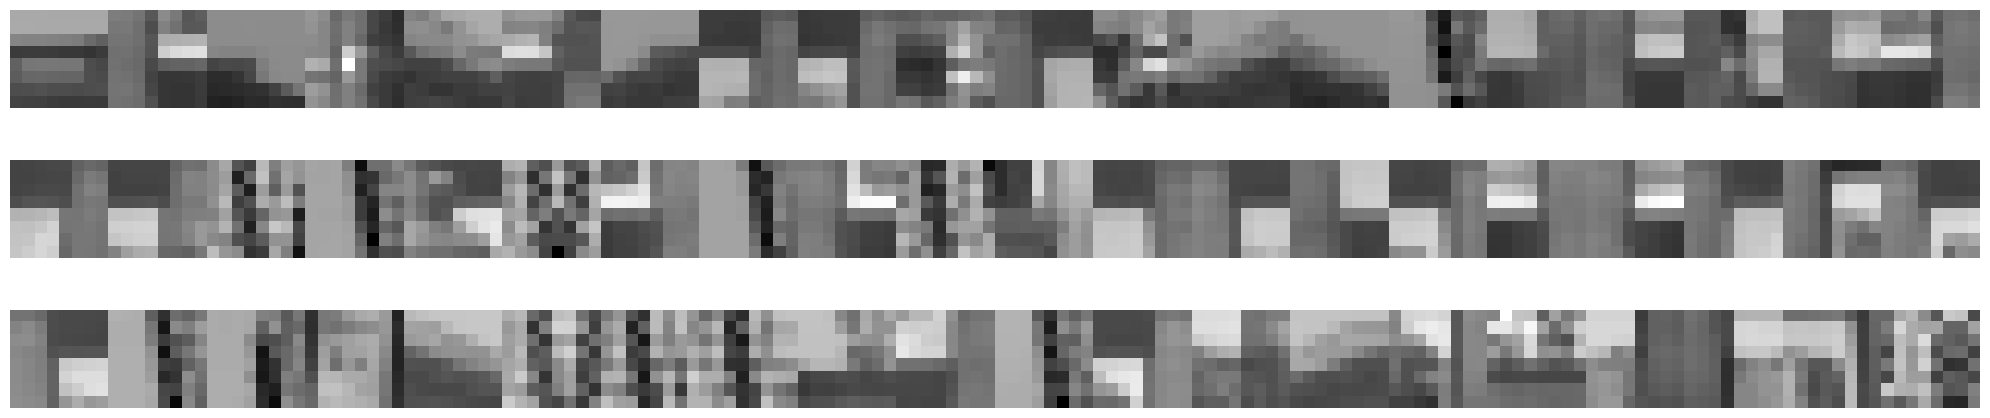

In [9]:
# Plot feature descriptors here
print(N_best.shape)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
desc, desc_coords = feature_desc(gray_img, N_best)
print(desc.shape, np.min(desc), np.max(desc))

fig, axes = plt.subplots(3, 1, figsize=(20, 5))

for row in range(3):
    start = row*20
    end = start+20

    patches = [d.reshape(8, 8) for d in desc[start:end]]

    strip = np.hstack(patches)

    axes[row].imshow(strip, cmap='gray')
    axes[row].axis('off')

plt.tight_layout()
plt.show()

# Part 5: Feature Matching [15 pts]

In the previous step, you encoded each keypoint by `64×1`
 feature vector. Now, you want to match the feature points among the two images you want to stitch together. In computer vision terms, this step is called as finding <u>feature correspondences</u> or <u>feature matching</u> between the 2 images. <br>

---

Sample Feature Matching: (Note some errors and bad matches)<br>
<img src="https://drive.google.com/uc?export=view&id=1S9Stx2qj_yk4VFoB28EuR_GQj2SOlYlR">

---
<br>


 1. Pick a point in image 1, compute sum of square difference between all points in image 2.
 2. Take the ratio of best match (lowest distance) to the second best match (second lowest distance) and if this is below some ratio keep the matched pair or reject it. Repeat this for all points in image 1.
 $$SSD=\sum(v_1−v_2)^2$$
 3. You will be left with only the confident feature correspondences and these points will be used later to estimate the transformation between the 2 images also called as Homography.

---
<br>
Brute-force matching compares every descriptor in one image to every descriptor in another image. While this method guarantees finding matches, it's computationally expensive and may not produce the best results due to its non-selective nature.


In [10]:
'''
Feature Matching
'''

def feature_matching(desc1, desc2):
    threshold_ratio = 0.7 #hyperparameter, to adjust as we see fit

    # Perform Feature Matching
    ssd_array = np.zeros((len(desc1), len(desc2)))
    for i in range(len(desc1)):
        for j in range(len(desc2)):
            feature1, feature2 = desc1[i], desc2[j]
            ssd = np.sum((feature1-feature2)**2)
            ssd_array[i][j] = ssd

  # Apply ratio test - check if the distance to the best match is significantly smaller than the distance to the second-best match.
      # If the ratio test passes, add the match to the list of matches.
      # Store the corresponding keypoints from image 1.
      # Store the corresponding keypoints from image 2.

    matches = np.zeros(len(desc1))
    i=0
    for row in ssd_array:
        indices = np.argpartition(row, 2)[:2]
        lowest_two = row[indices]
        best, second_best = min(lowest_two), max(lowest_two)
        if (best / second_best) > threshold_ratio:
            matches[i] = -1
        else:
            matches[i] = np.where(row == best)[0][0]#np.array(row).index(best)
        i+=1
    return matches

(450, 600, 3)


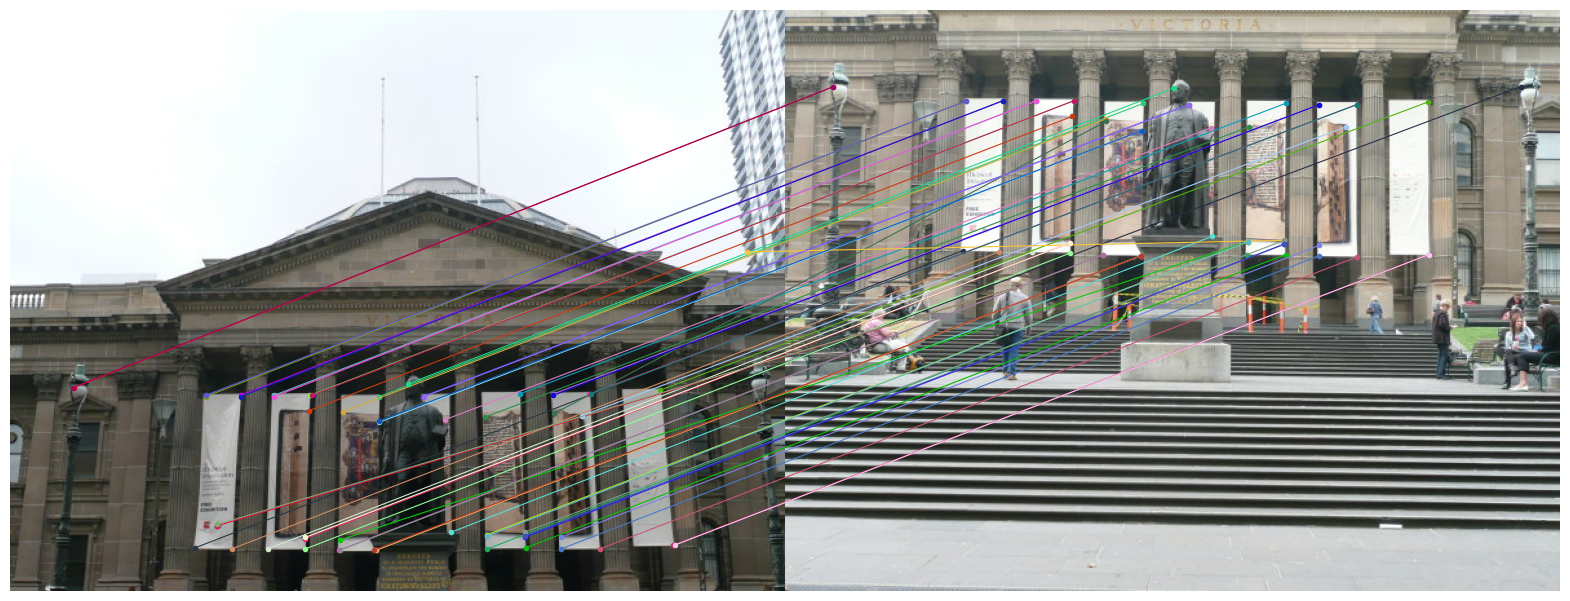

In [11]:
#add some kind of plotting or graphing
img2 = 'VictoriaLibrary/2.jpg'
img2 = mpimg.imread(img2)
# Detect corners for img2
N_strong2, dst2 = detect_corner(img2)
N_best2 = anms(dst2, N_strong2, 200)

gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
desc2, desc_coords2 = feature_desc(gray_img2, N_best2)

matches = feature_matching(desc, desc2)

plt.figure(figsize=(20, 10))
concatentated_images = cv2.hconcat([img, img2])
plt.imshow(concatentated_images)

image_length = img2.shape[1]
print(img2.shape)

match_kp1 = []
match_kp2 = []
for i in range(len(matches)):
  if matches[i] == -1:
    continue

  # x-coordinates (unpadded and shifted for img2)
  x1_plot = desc_coords[i][1]
  x2_plot = (desc_coords2[int(matches[i])][1]) + image_length

  # y-coordinates (unpadded)
  y1_plot = desc_coords[i][0]
  y2_plot = desc_coords2[int(matches[i])][0]

  match_kp1.append([int(x1_plot), int(y1_plot)])
  match_kp2.append([int(x2_plot) - image_length, int(y2_plot)])

  random_color = np.random.rand(3)
  plt.plot([x1_plot, x2_plot], [y1_plot, y2_plot], marker='o', linestyle='-',
           color=random_color, linewidth=0.8, markersize=3)
plt.axis('off')
plt.show()

match_kp1 = np.array(match_kp1)
match_kp2 = np.array(match_kp2)

# Part 6: Refine Matches [15 pts]

We now have matched all the features correspondences but not all matches will be right. To remove incorrect matches, we will use a robust method called Random Sampling Concensus or RANSAC to compute homography.

RANSAC, or Random Sample Consensus, is an iterative algorithm used to estimate the parameters of a mathematical model. In the context of image stitching, we can use RANSAC to estimate the transformation that maps points from one image to another. (Refer: [Wiki](en.wikipedia.org/wiki/Random_sample_consensus))

---

Sample Refined Feature Matching: (Note the <u>bad</u> feature matches disappeared)<br>
<img src="https://drive.google.com/uc?export=view&id=14BDjsDNMS3YCQ6ZvbNQBLtHEGBQv2zK9">

---
<br>

1. Select four feature pairs (at random), $p_i$ from `image 1`, $p^1_i$ from `image 2`.
2. Compute homography $H$ (exact). Write a function `est_homography`.
3. Compute inliers where $SSD(p^1_i,Hp_i)<\texttt{thresh}$. Here, $Hp_i$
 computed using another function that you will be writing `apply_homography`.
4. Repeat the last three steps until you have exhausted $N_\texttt{max}$ number of iterations (specified by user) or you found more than percentage of inliers (Say 90% for example).
5. Keep the largest set of inliers
6. Re-compute the least-square $\hat{H}$ estimate on all of the inliers.

In [12]:
'''
Performs RANSAC to find the best homography matrix.
  Input:
    match_kp1: A list of keypoints from image 1.
    match_kp2: A list of keypoints from image 2.
    iter: The maximum number of iterations.
    N: The number of inliers required for a model to be considered good.
    thr: The distance threshold for a point to be considered an inlier.

  Returns:
    H: The best homography matrix found.
    inliers1: The inliers from image 1.
    inliers2: The inliers from image 2.
'''
def RANSAC(match_kp1, match_kp2, iter, N, thr):
  # Perform RANSAC
  best_inliers = None
  for i in range(iter):
    four_sample = np.random.choice(len(match_kp1), 4, replace=False)
    H = est_homography(match_kp1[four_sample], match_kp2[four_sample])  # H: kp2 kp1
    projected = apply_homography(H, match_kp2)
    err = np.linalg.norm(projected - match_kp1, axis=1)
    inliers = err < thr   # 3–5 px is typical after a correct fit; 40 is very loose
    if best_inliers is None or inliers.sum() > best_inliers.sum():
      best_inliers = inliers
  H = est_homography(match_kp1[best_inliers].squeeze(), match_kp2[best_inliers].squeeze())
  return H, match_kp1[best_inliers].squeeze(), match_kp2[best_inliers].squeeze()

def est_homography(match_kp1, match_kp2):
  A = []
  for (x, y), (u, v) in zip(match_kp2, match_kp1):
    A.append([-x, -y, -1, 0, 0, 0, u*x, u*y, u])
    A.append([0, 0, 0, -x, -y, -1, v*x, v*y, v])
  _,  _, Vt = np.linalg.svd(np.array(A))
  H = Vt[-1].reshape(3, 3)
  return H / H[2, 2]

def apply_homography(H, pts):
  p = np.column_stack([pts, np.ones(len(pts))]) @ H.T
  return p[:, :2] / p[:, 2:3]

# Plot your updated feature matching results here (and visually compare them with the previous steps)

57 57
52 52


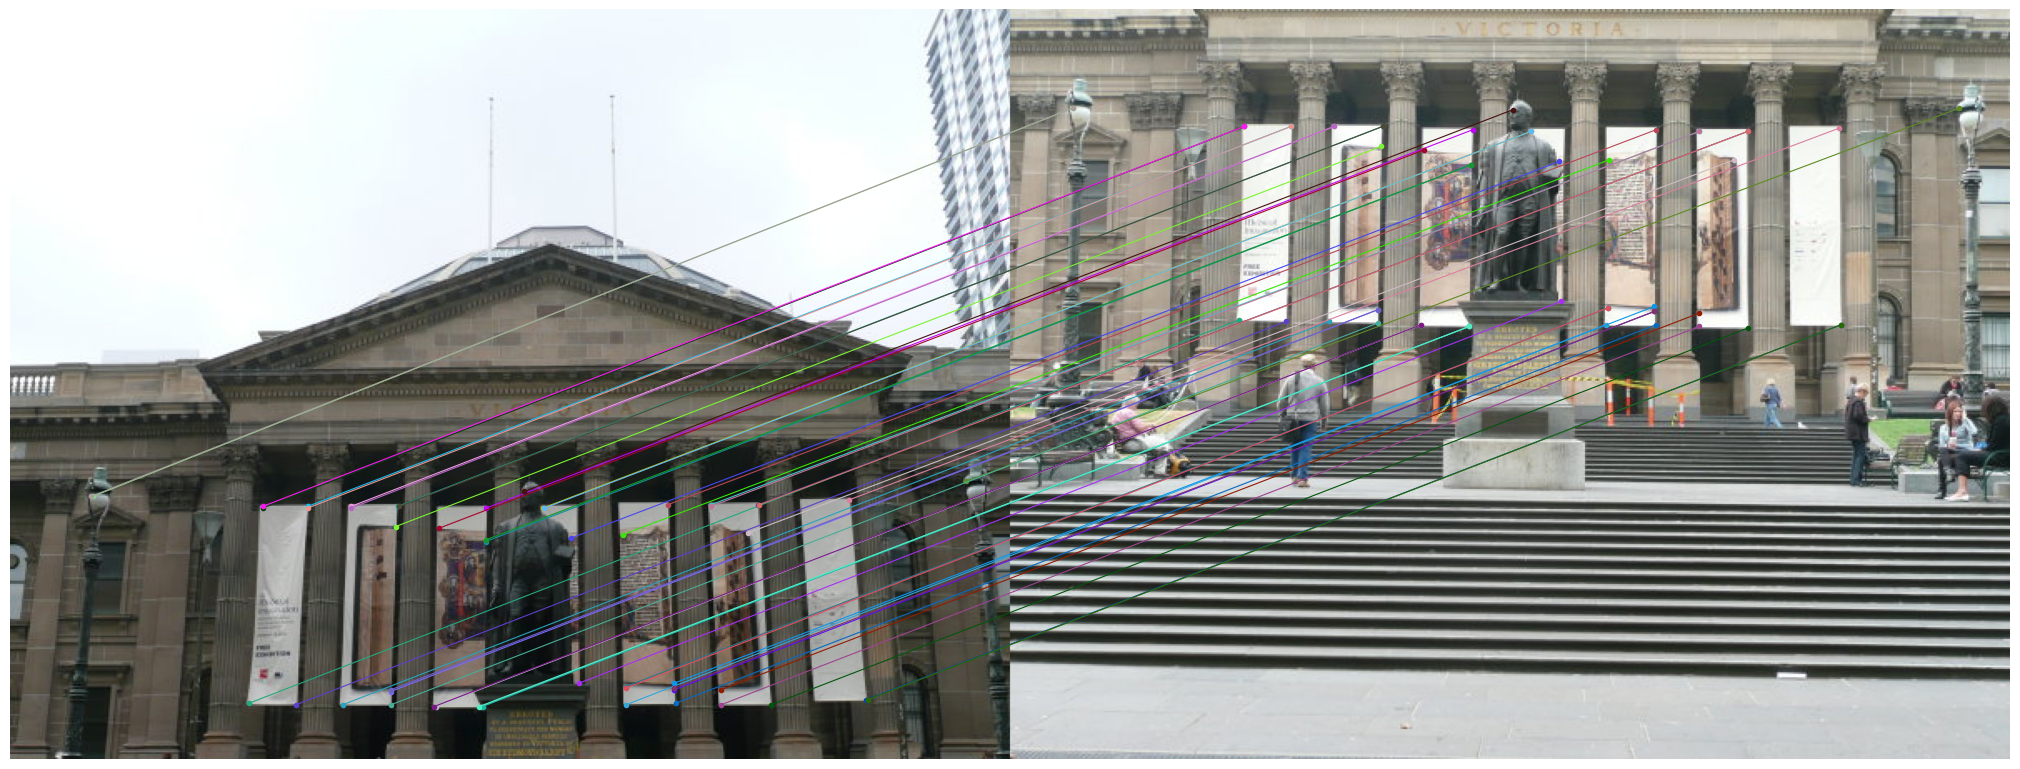

In [13]:
H, best_inliers1, best_inliers2 = RANSAC(match_kp1, match_kp2, 600, -1, 4)
print(len(match_kp1), len(match_kp2))
print(len(best_inliers1), len(best_inliers2))

plt.figure(figsize=(20, 7.5))
concatentated_images = cv2.hconcat([img, img2])
plt.imshow(concatentated_images)

image_length = img2.shape[1]

for i in range(len(best_inliers1)):
  # x-coordinates (unpadded and shifted for img2)
  x1_plot = best_inliers1[i][0]
  x2_plot = (best_inliers2[i][0]) + image_length

  # y-coordinates (unpadded)
  y1_plot = best_inliers1[i][1]
  y2_plot = best_inliers2[i][1]

  random_color = np.random.rand(3)
  plt.plot([x1_plot, x2_plot], [y1_plot, y2_plot], marker='o', linestyle='-',
           color=random_color, linewidth=0.8, markersize=3)

plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# Part 7: Warp and Blend [15 pts]

<b>Note: 15 pts extra credit for implementing everything from scratch for this section. </b>

Panorama can be produced by overlaying the pairwise aligned images to create the final output image. Understanding `cv2.warpPerspective` and `cv2.perspectiveTransform` functions will be helpful. For such implementation, apply bilinear tranpolation when you copy pixel values. Feel free to use any third party code for warping and transforming images.<br><br><hr>


Sample Final Warping and Blending Results: (Note the <u>bad</u> feature matches disappeared)<br>
<img src="https://drive.google.com/uc?export=view&id=18mSQS7rRYrbotlfKAAUfAkWWLOy5BApS" width="80%">

---
<br>

For a few datasets, you might need to perform cylindrical projection before warping and blending images together. This is because a simple projective transform such as homography will produce substandard results and the images will be stretched/shrunken to a large extent over the edges.<br>
<u><b>Note:</u> Feel free to use any open source code for this part.</b>

To overcome such distortion problem at the edges, we will be using cylinderical projection on the images first before performing other operations. Essentially, this is a pre-processing step. The following equations transform between normal image co-ordinates and cylinderical co-ordinates:

$$ x' = f \cdot tan \left(\cfrac{x-x_c}{f}\right) + x_c$$
$$ y' = \left(\cfrac{y-y_c}{cos \left(\cfrac{x-x_c}{f}\right)}\right) + y_c$$

These equations describe a cylindrical projection, where $f$ represents the focal length of the camera in pixels (typical values range from `100` to `500`). The original image coordinates $(x, y)$ are transformed into cylindrical coordinates $(x', y')$. The center of the image is denoted by $(x_c, y_c)$.

In [14]:
def feather_weight(mask):
    return cv2.distanceTransform(mask.astype(np.uint8), cv2.DIST_L2, 5)

def cylindrical_projection(x, y, f):
  pass

def warp_and_blend(img1, img2, H):
  # Warp and Blend
  # 1. Apply the perspective transformation to the corners of image2 using homography matrix H
  # 2. Calculate the minimum and maximum x and y coordinates from the concatenated corners
  # 3. Apply the perspective transformation to img1 with the combined transformation matrix @ H
  # Return Warped Image

  H_img, W = img2.shape[0], img2.shape[1]
  corners = np.float64([[0, 0], [W, 0], [W, H_img], [0, H_img]])
  warped = apply_homography(H, corners)
  x0, y0 = np.floor(np.minimum(warped.min(0), 0)).astype(int)
  x1, y1 = np.ceil(np.maximum(warped.max(0), [W, H_img])).astype(int)

  T = np.array([[1, 0, -x0], [0, 1, -y0], [0, 0, 1.0]])
  canvas_size = (x1 - x0, y1 - y0)
  warped2 = cv2.warpPerspective(img2, T@H, canvas_size)

  canvas1 = np.zeros_like(warped2)
  canvas1[-y0: -y0+H_img, -x0:-x0+W] = img1

#   result=warped2.copy()
#   mask = np.any(canvas1 != 0, axis=2)
#   result[mask] = canvas1[mask]
#   return result

  # Hint: Read about cv2.warpPerspective, cv2.perspectiveTransform.
  # Hint: You may need to perform cylindrical transformation for a few datasets
  # Hint: You may need to apply blending operations to match light, intensity, exposure, constrast etc.

  mask1 = np.zeros(canvas1.shape[:2])
  mask1[:img1.shape[0]-1, :img1.shape[1]-1] = 1
  mask2 = cv2.warpPerspective(np.ones(canvas1.shape[:2]), H, (canvas1.shape[1], canvas1.shape[0]))

  w1 = feather_weight(mask1.astype(np.uint8))
  w2 = feather_weight(mask2.astype(np.uint8))

  total = np.maximum(w1+w2, 1e-6)
  panorama  = (canvas1 * (w1/total)[..., None] + warped2*(w2/total)[..., None]).astype(np.uint8)

  return panorama

# Plot blended images here

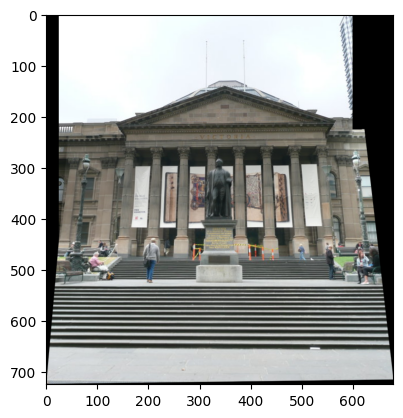

In [15]:
panorama = warp_and_blend(img, img2, H)
plt.imshow(panorama)

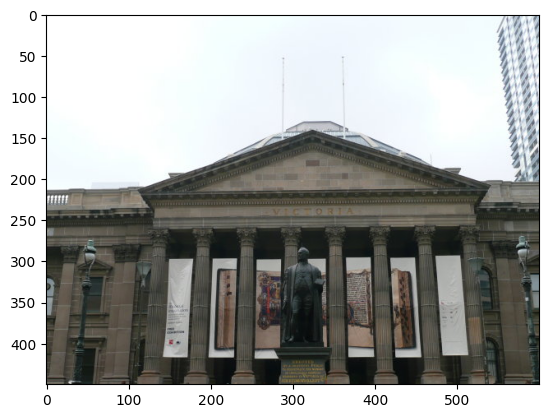

In [16]:
plt.imshow(img)

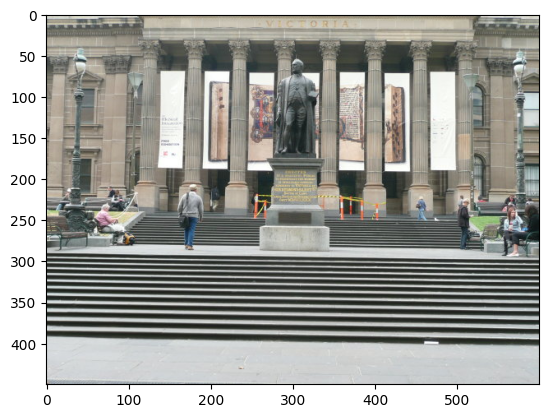

In [17]:
plt.imshow(img2)

Note: The pipeline talks about how to stitch a pair of images, you need to extend this to work for multiple images. You can re-run your images pairwise or do something smarter.

Your end goal is to be able to stitch any number of given images - maybe 2 or 3 or 4 or 100, your algorithm should work. If a random image with no matches are given, your algorithm needs to report an error.

Note: When blending these images, there are inconsistency between pixels from different input images due to different exposure/white balance settings or photometric distortions or vignetting. This can be resolved by algorithms such as Poisson blending. You can use third party code for the seamless panorama stitching.

# Final Stage: Putting Everything Together! [5 pts in total]

In [18]:
# Take in a list of images and stitch them together!
def mypano(img_list, flag = 0):
  # Use this function as a wrapper and call all the functions that you wrote here!
  # Feel free to use for loops to call functions (like corner detection) multiple times
  # 1. Load Images
  images = []
  descriptors = []
  descriptor_coordinates = []
  for img in img_list:
    this_image = mpimg.imread(img)
    desc, desc_coords = matching_info(this_image)
    images.append(this_image)
    descriptors.append(desc)
    descriptor_coordinates.append(desc_coords)


  n_composite = 0
  comp_img = images.pop(0)
  desc1 = descriptors.pop(0)
  desc_coords1 = descriptor_coordinates.pop(0)
  while n_composite < len(img_list)-1:


    num_matches = []
    H_list = []
    for i in range(len(images)):
      desc2 = descriptors[i]
      desc_coords2 = descriptor_coordinates[i]
      # 5. Feature Matching
      matches = feature_matching(desc1, desc2)
      # 6. RANSAC/Refine Matches
      match_kp1 = np.array([[int(desc_coords1[i][1]), int(desc_coords1[i][0])] for i, m in enumerate(matches) if m != -1])
      match_kp2 = np.array([[int(desc_coords2[int(m)][1]), int(desc_coords2[int(m)][0])] for m in matches if m != -1])
      H, best_inliers, _ = RANSAC(match_kp1, match_kp2, 600, -1, 4)
      H_list.append(H)
      num_matches.append(len(best_inliers))

    best_match = np.argmax(num_matches)
    H = H_list[best_match]
    img2 = images.pop(best_match)
    del descriptors[best_match]
    del descriptor_coordinates[best_match]

  # 7. Warp and Blend
    comp_img = warp_and_blend(comp_img, img2, H)
    desc1, desc_coords1 = matching_info(comp_img)
    n_composite += 1
  #
  # Return Stitched Image
  return comp_img


def matching_info(this_image):
# 2. Detect Corners
  N_strong, dst = detect_corner(this_image)
# 3. ANMS
  N_best = anms(dst, N_strong, 200)
# 4. Feature Descriptors
  gray_img = cv2.cvtColor(this_image, cv2.COLOR_BGR2GRAY)
  desc, desc_coords = feature_desc(gray_img, N_best)
  return desc, desc_coords


## Set 1 [5pts]: VictoriaLibrary

In [19]:
comp_img = mypano(['VictoriaLibrary/1.jpg', 'VictoriaLibrary/2.jpg', 'VictoriaLibrary/3.jpg'])
plt.imshow(comp_img)

/tmp/ipykernel_985/1055161996.py:40: RuntimeWarning: divide by zero encountered in divide
  return p[:, :2] / p[:, 2:3]


ValueError: could not broadcast input array from shape (724,680,3) into shape (450,600,3)

# Now perform the same task for other datasets. [20 pts in total]

You can change input arguments for different dataset

## Set 2 [5pts]


## Set 3 [5pts]

## Set 4 [5pts]


## Set 5 [5pts] (Extra Credit)


## Set 6 [5pts] (Extra Credit)


## Set 7 [5pts] (Extra Credit)
